In [12]:
%load_ext autoreload
%autoreload 1

import torch
import glob
import math
import PIL
import torchvision.transforms as transforms
import numpy as np

from mylib.plot import plot_imgs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
images_path = sorted(glob.glob(f"/media/leonardo/Leo_HD/data/TUM_RGBD_EPO/fr1_desk/rgb_syn/*"))[:5]

# load images
images = [PIL.Image.open(img_path) for img_path in images_path]
images_th = [transforms.ToTensor()(img).unsqueeze(0) for img in images]

# # resize to 518 long edge
min_size = int(images_th[0].shape[3] / (images_th[0].shape[2]/518))
resize_transform = transforms.Resize(min_size)
images_th = [resize_transform(img_th) for img_th in images_th]

# print sizes
for i, img_th in enumerate(images_th):
    print(f"Image {i}: {img_th.shape}")  # (1, 3, H, W)

Image 0: torch.Size([1, 3, 690, 920])
Image 1: torch.Size([1, 3, 690, 920])
Image 2: torch.Size([1, 3, 690, 920])
Image 3: torch.Size([1, 3, 690, 920])
Image 4: torch.Size([1, 3, 690, 920])


In [103]:
depth_paths = sorted(glob.glob(f"/media/leonardo/Leo_HD/data/TUM_RGBD_EPO/fr1_desk/depth_syn/*"))[:5]

# load images
depths = [PIL.Image.open(depth_path) for depth_path in depth_paths]
depth_nan = [np.where(dpth == 0, np.nan, dpth) for dpth in depths]
depth_norm =  [dpth_nan/5000 for dpth_nan in depth_nan]
depth_th = [transforms.ToTensor()(depth).unsqueeze(0) for depth in depth_norm]

# # resize to 518 long edge
min_size = int(depth_th[0].shape[3] / (depth_th[0].shape[2]/518))
resize_transform = transforms.Resize(min_size)
depth_th = [resize_transform(dpth_th) for dpth_th in depth_th]

# print sizes
for i, dpth_th in enumerate(depth_th):
    print(f"Image {i}: {dpth_th.shape}")  # (1, 3, H, W)

Image 0: torch.Size([1, 1, 690, 920])
Image 1: torch.Size([1, 1, 690, 920])
Image 2: torch.Size([1, 1, 690, 920])
Image 3: torch.Size([1, 1, 690, 920])
Image 4: torch.Size([1, 1, 690, 920])


In [ ]:
from extractors.canny import CannyEdgeDetector
canny_extractor = CannyEdgeDetector()

#from extractors.TEED.teed_wrapper import TeedWrapper
#teed_extractor = TeedWrapper(device="cuda")

# from extractors.DiffusionEdge.diffusion_edge_wrapper import DiffusionEdgeDetector
# diffedge = DiffusionEdgeDetector(device="cuda")

#from extractors.rcf_torch.rfc_wrapper import RCFWrapper
#rcf_extractor = RCFWrapper(device="cuda")



AttributeError: 'CannyEdgeDetector' object has no attribute 'shape'

In [122]:
k = 4
img_canny = canny_extractor(images_th[k]).squeeze().cpu()
#img_teed = teed_extractor(images_th[k], low_threshold=0.95, high_threshold=1.0).squeeze().cpu()
# img_diffedge = diffedge(images_th[k], low_threshold=0.01, high_threshold=0.05).squeeze().cpu()
#img_rcf = rcf_extractor(images[k], th=0.6667).squeeze().cpu()

# print non vers values
print(f"Canny: {torch.nonzero(img_canny).sum().item():,}")
#print(f"TEED: {torch.nonzero(img_teed).sum().item():,}")
# print(f"DiffusionEdge: {torch.nonzero(img_diffedge).sum().item():,}")
#print(f"RCF: {torch.nonzero(img_rcf).sum().item():,}")

Canny: 12,055,148


In [123]:
edge_mask = (depth_th[k] !=np.nan) & (img_canny > 0) & (depth_th[k] > 0)

masked_depth = depth_th[k] * edge_mask

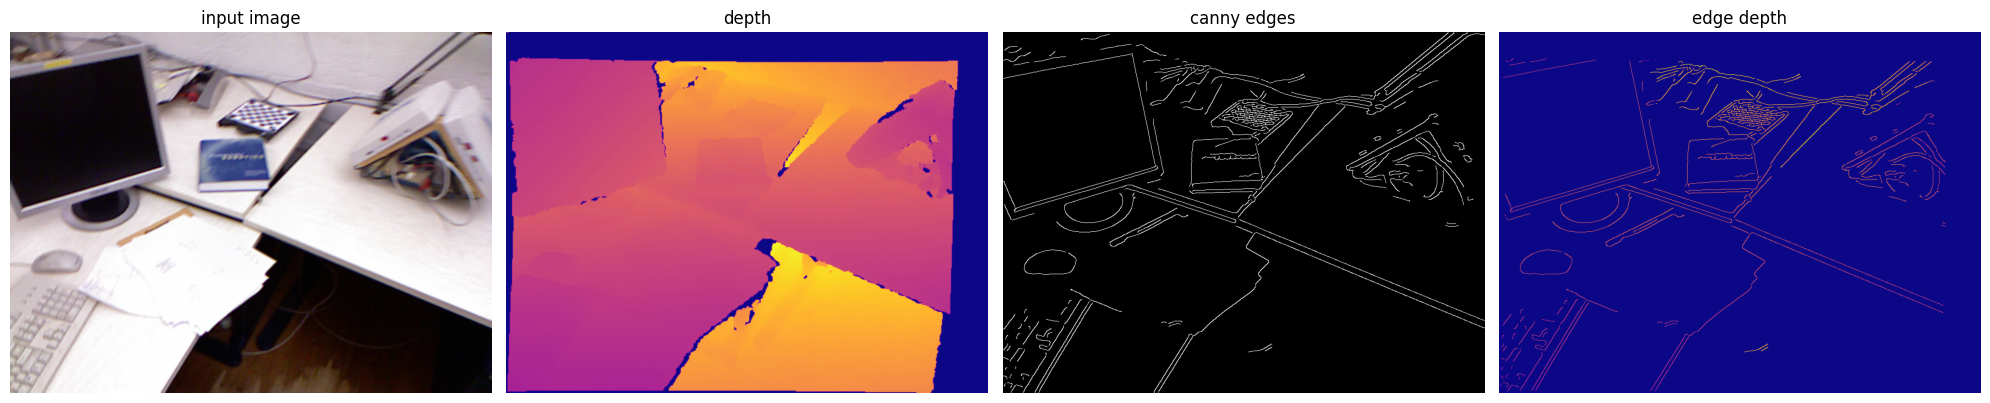

In [128]:
plot_imgs([
    images_th[k].squeeze().permute(1, 2, 0).cpu().numpy(),
    depth_th[k].squeeze().cpu().numpy(),
    img_canny, 
    masked_depth.squeeze(), 
    #img_teed,
    # img_diffedge
    #img_rcf
    ], 
    titles=["input image", "depth", "canny edges", "edge depth"],# "teed edges", "rcf edges"], 
            cmap=[None, "plasma", "gray", "plasma"], #"gray", "gray"],
    figsize=(20, 12)
)

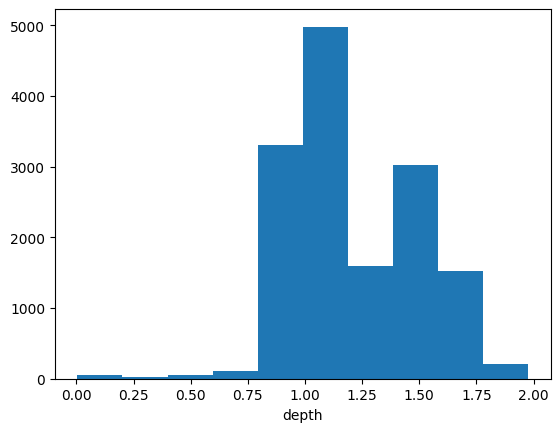

In [129]:
import matplotlib.pyplot as plt
plt.hist(masked_depth[masked_depth!=0].squeeze())
plt.xlabel("depth")
#plt.ylabel("pixels")
plt.show() 

In [126]:
zero_count = (masked_depth == 0).sum()
print(zero_count)

tensor(619946)


In [94]:
plt.close("all")

In [115]:
%timeit img_canny = canny_extractor(images_th[k]).squeeze().cpu()
%timeit img_teed = teed_extractor(images_th[k], low_threshold=0.8, high_threshold=1.0).squeeze().cpu()
%timeit img_diffedge = diffedge(images_th[k], low_threshold=0.01, high_threshold=0.05).squeeze().cpu()

7.66 ms ± 249 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


NameError: name 'teed_extractor' is not defined